### Anomaly Informed Remaining Useful Life Estimation (AIRULE) Using Hybrid LSTM models (June 2024)

available at: https://doi.org/10.1016/j.mex.2024.102555

### Initial Interpretation
- As a machine reaches failure, its RUL diminishes lineraly.
- However, estimating RUL prior the failure region is difficult

- This system not only informs the inception of anomalies but also forecasts the remaining operational life of the machinery.


- They use feature ranking and selection techniques
- They use unsupervised clustering algorithms for anomaly trend analysis & 

- Clip dataset an first signs of anomalies (not the entire dataset)

- RUL Regressor training & RUL prediction at the end

![AIRULE Methodology](./media/AIRULE_Method.png)

<br>
<hr>

### Informed Interpretation
Two parts (Methods essentialities):
1. Anomaly detection & anomaly onset identification
    Find when degredation begins (unsupervised)
2. Anomaly-triggered RUL estimation
    Once degredation begins (anomaly onset above), activate supervised model to predict RUL on only the degrading portion of the data

Super adaptable & versatile (use with any vibration sensor dataset!)

# Methodology
### Locating dataset

In [1]:
import os, sys

DATASET_LOC = "./Datasets/"
NASA_BEARING_DATASET_LOC = DATASET_LOC + "NASABearing/"
DEBUG = True

# For all sets_directories (not files) in dataset dir - Path.join is concatenates full path str lit to directory
sets_directories = [os.path.join(NASA_BEARING_DATASET_LOC, d)+f"/{d}/" for d in  os.listdir(NASA_BEARING_DATASET_LOC) if os.path.isdir(os.path.join(NASA_BEARING_DATASET_LOC, d))]

## Select Dataset ##
DATASET_DIR_INUSE = sets_directories[0]

if DEBUG:
    print("Available sets in Dataset are:")
    for i, dir in enumerate(sets_directories):
        print(f"[{i}] {dir}")
    # Using set/run 2
    print(f"Using set: {DATASET_DIR_INUSE}")


print(f"Count of bursts/files: {len(os.listdir(DATASET_DIR_INUSE))}")

Available sets in Dataset are:
[0] ./Datasets/NASABearing/1st_test/1st_test/
[1] ./Datasets/NASABearing/2nd_test/2nd_test/
[2] ./Datasets/NASABearing/3rd_test/3rd_test/
Using set: ./Datasets/NASABearing/1st_test/1st_test/
Count of bursts/files: 2156


### Feature Extraction - Features are scalars used during learning stages (You don't use raw data)

11 Features Total (so far (12/01 14:58))

<ins>Time Domain</ins>

- RMS
- Std
- Peak-to-Peak (PTP)
- Kurtosis
- Skewness
- Crest factor

<ins>Frequency Domain</ins>

- Spectral bandwidth (spread of frequencies)
- spectral centroid (center of mass of spectrum)
- Spectral total energy (overall vibration energy)
- Peak frequency (dominant vibration frequency)
- High-frequency energy ratio (Early fault indicator?)

In dissertation, might be worth noting these equation formualas. e.g.
Spectral Centroid:
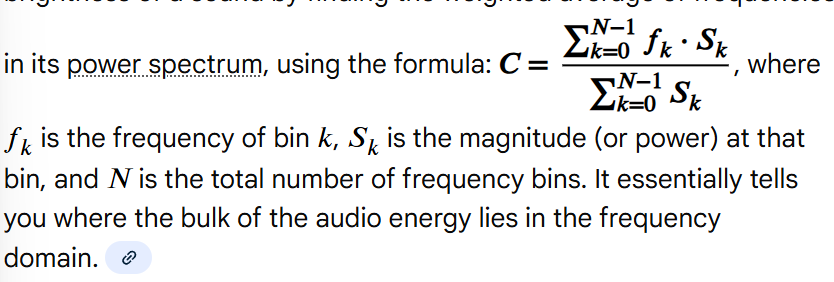

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Must check dataset in use - check num rows in  one burst
DATAPOINTS_PER_FILE = 20480
SAMPLE_RATE = 20000 # 20 kHz


time_step = 1 / SAMPLE_RATE
# np.arange returns arr of evenly spaced values within the given interval 
# so a float timestamp that can be used in timedelta at the 
# files starting point (such 2004.02.19.06.22.39) - there are 20480 
# datapoints which need time indexing/stamping
# Kind reminds me of pandas resample method but for relative (not actual) time in a given time period
timestamps = np.arange(DATAPOINTS_PER_FILE) * time_step
#print(timestamps)

features = [
    # Time Domain Features
    "rms",
    "std",
    "ptp",
    "kurtosis",
    "skew",
    "crest",

    # Frequency Domain Features
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_total",
    "high_frequency_ratio",
    "frequency_peak"
]

df = pd.DataFrame(columns=features) #columns=["b1", "b2", "b3", "b4"])


## ---- Time Domain Features
# Feature	Meaning
# RMS	Overall vibration energy
# Std	Signal spread
# Mean	Should be ~0 (after de-meaning)
# Peak-to-peak	Max impulse size
# Kurtosis	Impulsiveness (very important)
# Skewness	Asymmetry
# Crest factor	Peak / RMS
## ---- Calcuation
# Where x the 20480 readings in a burst for the deterioted bearing (b1)
# Time Domain Features = {
#     "rms": np.sqrt(np.mean(x**2)),
#     "std": np.std(x),
#     "ptp": np.ptp(x),
#     "kurtosis": stats.kurtosis(x, fisher=False),
#     "skew": stats.skew(x),
#     "crest": np.max(np.abs(x)) / np.sqrt(np.mean(x**2))
# }
# Frequency Domain Features = {
#     ""
# }


BEARINGS_COUNT:int # not implemented sensor-fusion on single bearing (point) yet
CSV_DELIM:str = "\t"
# Parse & understand CSV files in dataset 
with open(DATASET_DIR_INUSE+os.listdir(DATASET_DIR_INUSE)[0]) as file:
    line = file.readline()
    NUMERICAL_CHARS = [".", "-", "+"] # Doesnt count unary values, decimal points as delimeters
    for char in line:
        if not char.isnumeric() and char not in NUMERICAL_CHARS:
            print(f"Suspected Delimiter: '{char}'")
            CSV_DELIM = char
            break
    cols = line.count(CSV_DELIM) + 1
    print(f"Bearings (coloums) found: {cols}")
    BEARINGS_COUNT = cols



for file_reading_interval in os.listdir(DATASET_DIR_INUSE):
    # Each iteration is a burst (file contains one burst)
    

    # print(file_reading_interval)
    time_interval_df = pd.read_csv(
        DATASET_DIR_INUSE+file_reading_interval, 
        delimiter=CSV_DELIM, 
        # [b1, b2, ..., bn]
        names=["b"+str(i+1) for i in range(BEARINGS_COUNT)], header=None)
    
    start = pd.to_datetime(file_reading_interval, format="%Y.%m.%d.%H.%M.%S")
    time_interval_df.index = start + pd.to_timedelta(timestamps, unit="s")

    # print(f"reading starts at: {time_interval_df.index[0]}")
    # print(f"reading ends at: {time_interval_df.index[-1]}")
    # print(time_interval_df)
    # break

    try:
        bearings_readings = time_interval_df["b5"]
    except KeyError as err:
        print("\n[CAUGHT ERROR]: File(s) for set selected doesnt have this many columns?")
        break


    # TIME DOMAIN
    td_features_dict = {}
    
    td_features_dict["id"] = file_reading_interval

    td_features_dict["rms"] = np.sqrt(np.mean(bearings_readings**2))
    td_features_dict["std"] = np.std(bearings_readings)
    td_features_dict["ptp"] = np.ptp(bearings_readings)
    td_features_dict["kurtosis"] = stats.kurtosis(bearings_readings, fisher=False)
    td_features_dict["skew"] = stats.skew(bearings_readings)
    td_features_dict["crest"] = np.max(np.abs(bearings_readings)) / np.sqrt(np.mean(bearings_readings**2))
    
    # FREQUENCY DOMAIN
    fd_features_dict = {}
    # Convert time-domain to FFT domain
    fft_b1_burst = np.fft.rfft(list(bearings_readings))
    # bring to positive (>= 0)
    magnitude = np.abs(fft_b1_burst)
    frequencies = np.fft.rfftfreq(len(bearings_readings), d=1/DATAPOINTS_PER_FILE) # 1/sample rate per burst (20480)
    # First reading is normally super high (the first value when using the FFT 
    # formular is set to the sum of all the samples in this signal instance - apprently)
    # so set it to 0 to remove this dominance
    magnitude[0] = 0

    # Bins in FFT are frequency slots (indicates strength of vibration at that frequency)
    # The readings (20480 rows) becoems: 20480 / 2 + 1 = 10241 frequency bins 


    fd_features_dict["spectral_centroid"] = np.sum(frequencies * magnitude) / np.sum(magnitude)
    fd_features_dict["spectral_bandwidth"] = np.sqrt(np.sum(((frequencies - fd_features_dict["spectral_centroid"]) ** 2) * magnitude) / np.sum(magnitude))
    fd_features_dict["spectral_total"] = np.sum(magnitude**2)
    # High Freqs energy ratio (threshold is >5kHz) 
    THRESHOLD = 5000
    fd_features_dict["high_frequency_ratio"] = np.sum(magnitude[frequencies > THRESHOLD]**2) / fd_features_dict["spectral_total"] 
    # np.argmax Finds & Returns the indices of the maximum values along an axis (idx of largest val in magnitude).
    fd_features_dict["frequency_peak"] = frequencies[np.argmax(magnitude)]
    # Extra NOTE
    # - Spectral bandwidth (spread of frequencies)
    # - spectral centroid (center of mass of spectrum)
    # - Spectral total energy (overall vibration energy)
    # - Peak frequency (dominant vibration frequency)
    # - High-frequency energy ratio (Early fault indicator?)
    
    features_dict = {**td_features_dict, **fd_features_dict}


    df.loc[len(df)] = features_dict

df.index = os.listdir(DATASET_DIR_INUSE)
df.index = pd.to_datetime(df.index, format="%Y.%m.%d.%H.%M.%S")


print(df)
print(f"{df.shape} (number of bursts ROW, number of features per burst COL)")

Suspected Delimiter: '	'
Bearings (coloums) found: 8
                          rms       std    ptp   kurtosis      skew  \
2003-10-22 12:06:24  0.128887  0.091461  0.896   3.405439  0.034372   
2003-10-22 12:09:13  0.129562  0.091732  1.059   3.445718  0.001097   
2003-10-22 12:14:13  0.131339  0.091813  0.987   3.389712  0.053072   
2003-10-22 12:19:13  0.131083  0.092385  0.874   3.261962 -0.023654   
2003-10-22 12:24:13  0.131307  0.091932  0.998   3.326192  0.027080   
...                       ...       ...    ...        ...       ...   
2003-11-25 16:07:32  0.275645  0.250236  5.825   7.150598 -0.089556   
2003-11-25 23:13:21  0.496173  0.483099  9.651  14.721414 -0.129049   
2003-11-25 23:19:56  0.531569  0.520574  9.902  14.270747 -0.083697   
2003-11-25 23:29:56  0.474447  0.459749  9.191  12.388587 -0.303925   
2003-11-25 23:39:56  0.593610  0.579418  9.998   8.902675  0.067194   

                         crest  spectral_centroid  spectral_bandwidth  \
2003-10-22 12:06:24  

<Axes: >

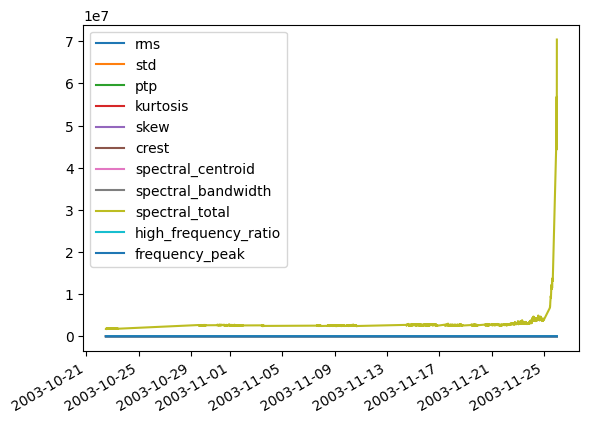

In [3]:
df.plot()

## Feature Normalisation (scaling all features to shared scale)
Imperative before using KMeans clustering. otherwise, larger spanning features (spectral energy) will be the dominating feature - all features should be fairly assessed.
 

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(df[features].values)

df_scaled = pd.DataFrame(features_scaled, columns=features, index=df.index)
df_scaled

,rms,std,ptp,kurtosis,skew,crest,spectral_centroid,spectral_bandwidth,spectral_total,high_frequency_ratio,frequency_peak
2003-10-22 12:06:24,-1.517142,-1.006162,-0.741126,-0.285287,0.265050,-0.666860,2.227271,1.175711,-0.455892,1.222537,-0.083776
2003-10-22 12:09:13,-1.486066,-0.994771,-0.572654,-0.277977,0.082990,-0.491227,2.130776,0.973014,-0.451779,1.087621,-0.083776
2003-10-22 12:14:13,-1.404271,-0.991382,-0.647071,-0.288141,0.367368,-0.421212,2.607660,1.276615,-0.450566,1.442662,-0.083776
2003-10-22 12:19:13,-1.416060,-0.967358,-0.763865,-0.311325,-0.052433,-0.544394,2.478084,1.266384,-0.441844,1.783762,-0.083776
2003-10-22 12:24:13,-1.405721,-0.986395,-0.635702,-0.299669,0.225157,-0.611103,2.484288,1.217155,-0.448767,1.538115,-0.083776
...,...,...,...,...,...,...,...,...,...,...,...
2003-11-25 16:07:32,5.238909,5.659494,4.353350,0.394377,-0.413020,1.753588,-0.442181,-3.798136,4.019997,1.345507,6.838514
2003-11-25 23:13:21,15.390989,15.435488,8.307796,1.768313,-0.629103,1.434653,2.575726,-10.253409,18.108109,5.699707,9.922187
2003-11-25 23:19:56,17.020442,17.008779,8.567223,1.686527,-0.380960,1.209478,2.693045,-9.291209,21.211345,6.793102,6.859813
2003-11-25 23:29:56,14.390809,14.455239,7.832353,1.344957,-1.585934,1.502859,1.403218,-8.124205,16.292311,5.285621,9.917453


## KMeans Clustering
Clustering used to identify healthy vs abnormal datapoints (so no labels needed - making this approach an unsupervised learning!)

label 0 = Health
- RMS = low vib energy
- Kurtosis around 3-4 (close to gaussian noise)
- High-Freq ratio low = no impulsive fault energy

label 1 = Unhealthy
- RMS = vib energy increaing
- kurtosis > 3.7 (using NASA bearing ds) = impulsive events
- High-Freq ratio higher = fault related frequencies


c:\Users\Patri\Desktop\Uni\Level 6\Individual Project\Analysis\Vibration Analysis\main\v\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


                     rms  kurtosis  high_frequency_ratio
cluster_labels                                          
0              -0.165331 -0.235166              0.075105
1               1.371104  1.950257             -0.622851


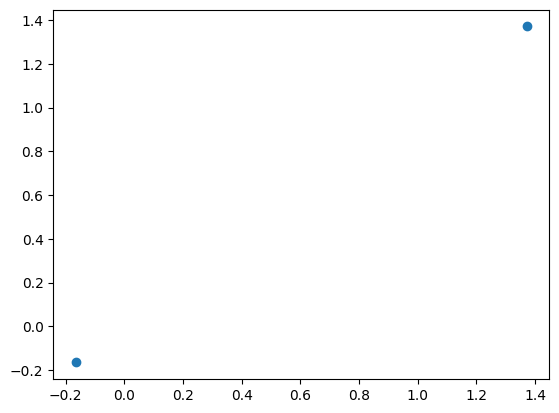

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# Two groups (healthy, unhealthy)
kmeans = KMeans(n_clusters=2, random_state=42).fit(features_scaled) # Do not include RUL nor time-indexing (just the feature columns)

df_scaled["cluster_labels"] = kmeans.labels_
df["cluster_labels"] = kmeans.labels_

cluster_means = df_scaled.groupby("cluster_labels").mean()
print(cluster_means[["rms", "kurtosis", "high_frequency_ratio"]])


plt.scatter(cluster_means["rms"], cluster_means["rms"])
plt.show()

Lower RMS, Kurtosis, Spectral total & Spectral centroid agree that **label 0 is healthy** & **label 1 is degrading**

Looking at High-Frequency Feature: 

cluster 0 len: 1924
cluster 1 len: 232
Cluster 0 min-max: 0.428-0.548 (Spread is 0.12)
Cluster 1 min-max: 0.406-0.613 (Spread is 0.207)


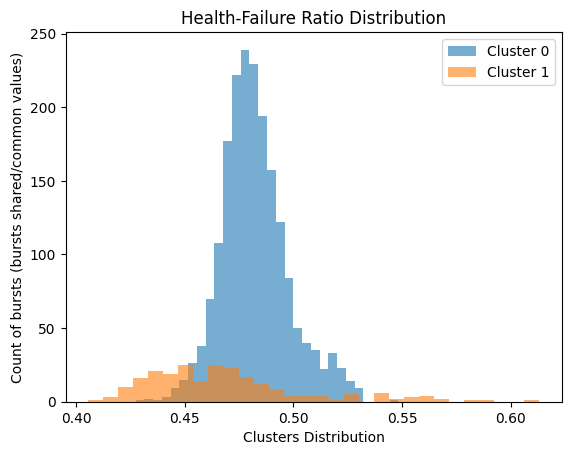

,rms,kurtosis,spectral_total,spectral_centroid
cluster_labels,,,,
0,0.158252,3.681621,2.598018e+06,4759.758479
1,0.191627,15.723981,5.526839e+06,4665.103341


In [41]:
import matplotlib.pyplot as plt

cluster0 = df[df["cluster_labels"] == 0]
cluster1 = df[df["cluster_labels"] == 1]
print("Looking at High-Frequency Feature: \n")
print(f"cluster 0 len: {len(cluster0)}")
print(f"cluster 1 len: {len(cluster1)}")
c0_min = round(cluster0['high_frequency_ratio'].min(), 3); c0_max = round(cluster0['high_frequency_ratio'].max(), 3)
c1_min = round(cluster1['high_frequency_ratio'].min(), 3); c1_max = round(cluster1['high_frequency_ratio'].max(), 3)
print(f'Cluster 0 min-max: {c0_min}-{c0_max} (Spread is {round(c0_max - c0_min, 3)})')
print(f'Cluster 1 min-max: {c1_min}-{c1_max} (Spread is {round(c1_max - c1_min, 3)})')

# PLot
plt.hist(cluster0['high_frequency_ratio'], bins=30, alpha=0.6)
plt.hist(cluster1['high_frequency_ratio'], bins=30, alpha=0.6)
plt.xlabel("Clusters Distribution")
plt.ylabel("Count of bursts (bursts shared/common values)")
plt.legend(['Cluster 0', 'Cluster 1'])
plt.title('Health-Failure Ratio Distribution')
plt.show()

df.groupby('cluster_labels').mean()[[
    'rms', 'kurtosis', 'spectral_total', 'spectral_centroid'
]]

From above, can see Cluster 1 (anomalous values) are more spread on x axis, wheres in Cluster 0 (healthy values), they're tightly around the same healthy margin. 

Now we've got the seperation, we can use the healthy data (label 0) for the autoencoder!

In [38]:
#df_scaled

In [40]:
healthy_df = df_scaled.loc[df_scaled["cluster_labels"]==0][features]
healthy_data = healthy_df.values

print("Shape format here (bursts count/rows, features count/cols)")
print(f"Health labelled data: {healthy_data.shape} - (All data: {df_scaled.shape})")

# Sequence length is the amount of consecutive bursts to join together for assessing (rather than just 1 individual burst)
SEQUENCE_LENGTH = 20
healthy_sequences = []
for i in range(len(healthy_data) - SEQUENCE_LENGTH + 1):
    healthy_sequences.append(healthy_data[i:i+SEQUENCE_LENGTH])
healthy_sequences = np.array(healthy_sequences)


print(f"Sequences: {healthy_sequences.shape}")


Shape format here (bursts count/rows, features count/cols)
Health labelled data: (1924, 11) - (All data: (2156, 12))
Sequences: (1905, 20, 11)


## LSTM Auto Encoder!

Revise components in Sequential Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

features_count = len(features)

autoencoder = Sequential([
    # Input Layer - Using ReLU as paper, if exploding reconstruction error or dead neurons detected tne use tanh
    LSTM(64, activation="ReLU", input_shape=(SEQUENCE_LENGTH, features_count), return_sequences=False),
    RepeatVector(SEQUENCE_LENGTH), 
    # Output Layer
    LSTM(64, activation="ReLU", return_sequences=True),
    TimeDistributed(Dense(features_count))
])

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                19456     
                                                                 
 repeat_vector (RepeatVecto  (None, 20, 64)            0         
 r)                                                              
                                                                 
 lstm_1 (LSTM)               (None, 20, 64)            33024     
                                                                 
 time_distributed (TimeDist  (None, 20, 11)            715       
 ributed)                                                        
                                                                 
Total params: 53195 (207.79 KB)
Trainable params: 53195 (207.79 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
# Check data is scaled (MSE was enormous as was using unscaled data by accident)
print(healthy_data.shape)

print(f"Min: {healthy_data.min()}")
print(f"Max: {healthy_data.max()}")
print(f"Mean: {healthy_data.mean()}")
print(f"Std: {healthy_data.std()}")


(1924, 11)
Min: -2.834690428454364
Max: 3.462861600230938
Mean: -0.07421034007309381
Std: 0.4886240007480137


Now train the model with the healthy data

In [11]:
# Healthy Sequences is the healthy training data remember

history = autoencoder.fit(
    healthy_sequences,
    healthy_sequences,
    epochs=50,
    batch_size=32,
    validation_split=.1, # Ratio 
    shuffle=True
    )

print(f"Loss: {np.mean(history.history['loss'])}")
print(f"Val Loss: {np.mean(history.history['val_loss'])}")


Epoch 1/50
54/54 [==============================] - 6s 34ms/step - loss: 0.0984 - val_loss: 0.2468
Epoch 2/50
54/54 [==============================] - 1s 24ms/step - loss: 0.0524 - val_loss: 0.2248
Epoch 3/50
54/54 [==============================] - 1s 24ms/step - loss: 0.0467 - val_loss: 0.2574
Epoch 4/50
54/54 [==============================] - 1s 23ms/step - loss: 0.0452 - val_loss: 0.2136
Epoch 5/50
54/54 [==============================] - 1s 23ms/step - loss: 0.0447 - val_loss: 0.2020
Epoch 6/50
54/54 [==============================] - 1s 25ms/step - loss: 0.0444 - val_loss: 0.2746
Epoch 7/50
54/54 [==============================] - 1s 25ms/step - loss: 0.0439 - val_loss: 0.7868
Epoch 8/50
54/54 [==============================] - 1s 25ms/step - loss: 0.0436 - val_loss: 0.3873
Epoch 9/50
54/54 [==============================] - 1s 24ms/step - loss: 0.0433 - val_loss: 1.8306
Epoch 10/50
54/54 [==============================] - 1s 23ms/step - loss: 0.0429 - val_loss: 0.9493
Epoch 11/

All data (both healthy & unhealthy)

In [12]:
all_data = df_scaled[features].values
print(all_data.shape)


all_sequences = []
for i in range(len(all_data) - SEQUENCE_LENGTH + 1):
    all_sequences.append(all_data[i:i+SEQUENCE_LENGTH])
all_sequences = np.array(all_sequences)

all_sequences.shape

(2156, 11)


(2137, 20, 11)

Anomaly Scores (health indicators)

<br>
Image shows autoencoder & decoder - taking the healthy data as input, outputting or "reconstructing" the data as an expected healthy state - the reconstruction error is how close it is to the original data fed in. so the anomalies will have a much larger error/distance from original data on reconstruction as it is unexpected values! This triggers anomaly detector then, and the most initial anomaly (first anomalous datapoint to go over threshold) is the onset degradation - this is where RUL countdown begins... Tick Tock...

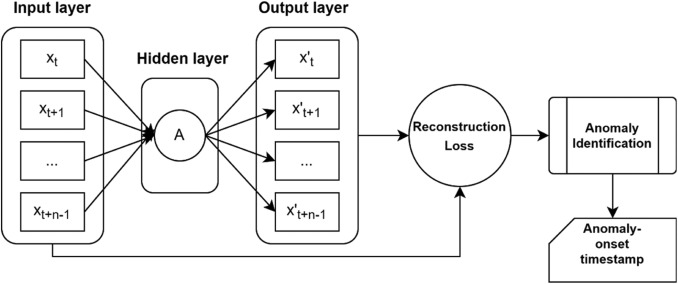

In [13]:
# Predict what the continuing data should look like if healthy
reconstruction = autoencoder.predict(all_sequences)

reconstruction_error = np.mean((all_sequences - reconstruction)**2, axis=(1,2))
reconstruction_error

# Errors aligned with original timeline (bursts times) NOTE - First burst doesnt have an error (error is corresponds to last burst of each sequence)
error_series = pd.Series(
    reconstruction_error,
    index=df.index[SEQUENCE_LENGTH - 1:]
)
error_series


67/67 [==============================] - 1s 8ms/step


2003-10-22 13:39:13        0.038710
2003-10-22 13:44:13        0.040522
2003-10-22 13:49:13        0.043245
2003-10-22 13:54:13        0.042881
2003-10-22 13:59:13        0.043297
                           ...     
2003-11-25 16:07:32    12159.065404
2003-11-25 23:13:21    12656.254514
2003-11-25 23:19:56    14504.849129
2003-11-25 23:29:56    22207.968590
2003-11-25 23:39:56     3979.844319
Length: 2137, dtype: float64

### We now effectively have health scores 

Spikes are indicative of unexpected values, not seen during training (in healthy state). These pick up near the end of the time-series data as expected, beacuse this is where the bearing is wearing out.

The reconstruction loss (distance from predicted "expected healthy" datapoints to the actual datapoint value) are indicative of the machines health. the larger the reconstruction loss/error, the worser the health as it is further from the expected healthy range.

"anomaly scores", "health indicator", "reconstruction error", "reconstruction loss" are interchangable terminology for this:

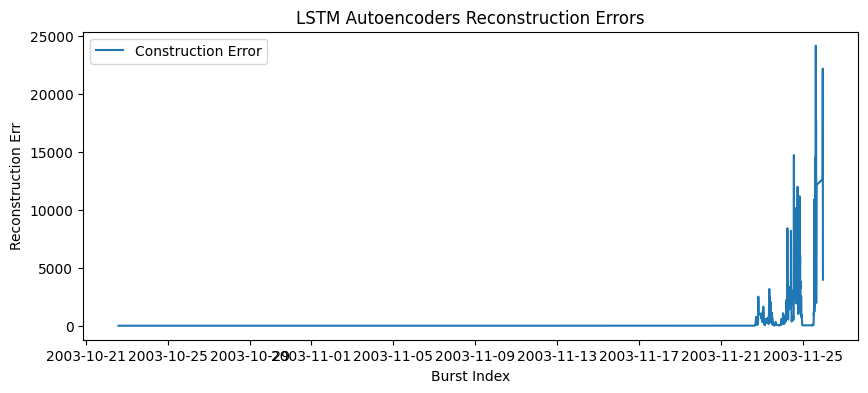

In [14]:
plt.figure(figsize=(10,4))
plt.plot(error_series, label="Construction Error")
plt.title("LSTM Autoencoders Reconstruction Errors")
plt.xlabel("Burst Index")
plt.ylabel("Reconstruction Err")

plt.legend()
plt.show()

### Finding Anomaly onset timestamp 
So after the onset (first genuine anomaly spike), the machine is entering its degradation period

Threshold: 1074.7883943807462
Abnormal Values found: 125
Intitial anomaly onset: 2003-11-22 19:56:56


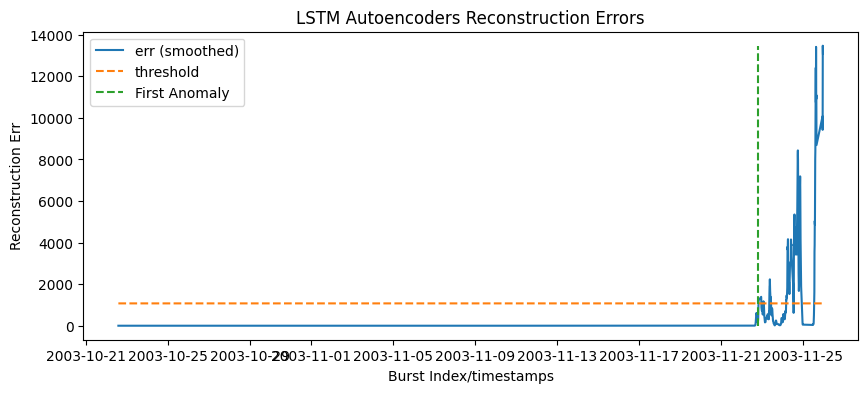

In [15]:
healthy_error = error_series.loc[healthy_df.index[SEQUENCE_LENGTH-1:]]
# Smoothing ensures that anomaly occurances persist over more than one burst (window=5)
# Thus, good for reducing false positives
smoothed_error = error_series.rolling(window=5, min_periods=1).mean()


mu = healthy_error.mean() # mu μ is terminology in math for mean
sigma = healthy_error.std() # Sigma σ is terminology in math for std 

# Formula is "Upper Control Limit" - Three-Sigma Rule (https://www.geeksforgeeks.org/maths/68-95-99-rule/)
threshold = mu + 3 * sigma
print(f"Threshold: {threshold}")

# Anomalies are those with errors above threshold
anomalies = error_series[error_series > threshold]
print(f"Abnormal Values found: {len(anomalies)}")

# Beginning of anomalous/unexpected behaviour
first_abnormal_idx = error_series[error_series > threshold].index[0]
print(f"Intitial anomaly onset: {first_abnormal_idx}")

plt.figure(figsize=(10,4))
plt.plot(smoothed_error, label="err (smoothed)")
plt.plot(error_series.index, [threshold for _ in range(len(error_series))], label="threshold", linestyle="--")
plt.plot([first_abnormal_idx,first_abnormal_idx],[0,smoothed_error.max()], label="First Anomaly", linestyle="--")
plt.title("LSTM Autoencoders Reconstruction Errors")
plt.xlabel("Burst Index/timestamps")
plt.ylabel("Reconstruction Err")
plt.legend()
plt.show()

### Important Note before looking at below Estimating RUL
THIS APPROACH IS KNOWING THE FAILURE (tf)
This approach below is using the NASA bearing dataset which is run-to-failure.Therefore, we can use the below forumla as we know when/what tf is (the end of the degradation period is the failure "tf"). 

Using this approach on an unknown machine would require that:
- The machine(s) this entire notebook is calibrated & predicting for are similar in configuration/placement of sensors & structure of machine. (obvious)
- The machine(s) are ran to failure a few times & tracked, to gather degradation period for the RUL regression prediction below

<br>
<hr>

Alternative to the regression based RUL is Health-based RUL.
Where instead of predicting time till failure, we predict the distance to failure in latent health space. 
So, 
- How fast anomaly scores (reconstruction errors) are growing


<br>
<br>
<br>

### Estimating RUL (Regression Based) 
Training data required is the degredation period (near end of life) 

Clip dataset at anomaly onset time to failure (end)

<br>

![RUL Forumla from clipped dataset](media/Regressive_RUL.png)

- ta = First genuine anomaly (anomaly onset time)
- tf = Last datapoints in clipped degradation (failure time)
- t = current datapoint in clipped dataset

In [16]:
# Col is Construction Error (loss)
# for t >= ta
degradation_period = smoothed_error[first_abnormal_idx:]
degradation_period_df = pd.DataFrame(degradation_period, columns=["R_Error"])
# Data is now clipped, from the onset of degradation onwards to end as shown in the paper
degradation_period_df

# Last datapoint (tf)
failure_timestamp = degradation_period_df.index[-1]
failure_timestamp

degradation_period_df["RUL_seconds"] = (failure_timestamp - degradation_period_df.index).total_seconds()
degradation_period_df


,R_Error,RUL_seconds
2003-11-22 19:56:56,791.198380,272580.0
2003-11-22 20:06:56,1074.165012,271980.0
2003-11-22 20:16:56,1223.227636,271380.0
2003-11-22 23:14:58,1384.461557,260698.0
2003-11-22 23:16:56,1390.830327,260580.0
...,...,...
2003-11-25 16:07:32,8693.144274,27144.0
2003-11-25 23:13:21,10076.079064,1595.0
2003-11-25 23:19:56,9426.554158,1200.0
2003-11-25 23:29:56,13475.520018,600.0


<Axes: >

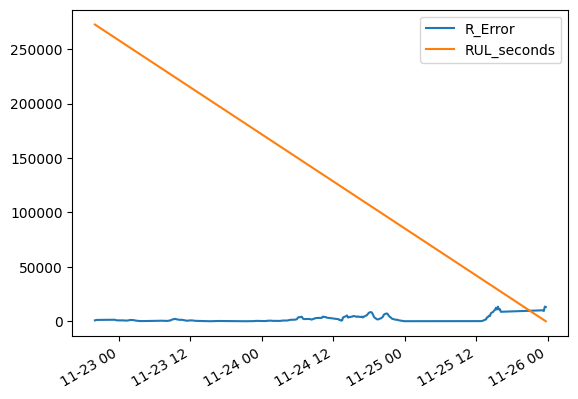

In [17]:
degradation_period_df.plot()

### Estimating RUL (Live Conditinal-Health-Based)
so instead of looking at current t-t_failure, score RUL depending on the speed of increase on the anomaly score (reconstruction errors)

This doesn't give an absolute/exact time of failure - as this is impossible. Although this gives a pretty good indicator that actions are required & the impending failures arising. This is monitors current conditions and the growing change in abnormal sensor readings 

![Health Based RUL forumla from onset onwards](media/HealthBased_RUL.png)

![](media/HealthBased_RUL2.png)


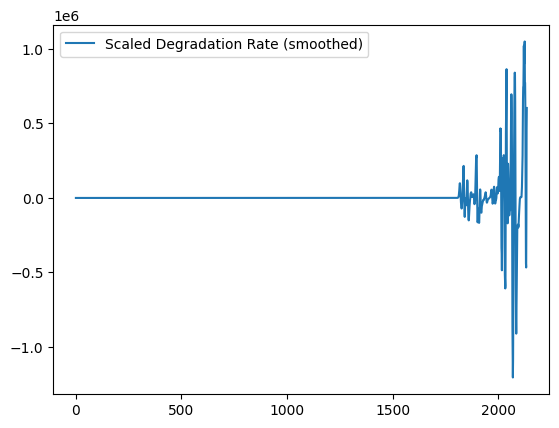

In [ ]:
critical_health_threshold = threshold
# Beyond this point, the machine is becoming uncomfortable to continue operating (requires attention & maintanence)
critical_health_threshold

# Slope I believe 
estimated_degradation_rate = np.gradient(smoothed_error.values) # np.gradient(smoothed_error.values)
rate_smoothed = pd.Series(estimated_degradation_rate).rolling(5, min_periods=1).mean()

rate_smoothed

# ?
epsilon = 1e-6

RUL_health = (critical_health_threshold - smoothed_error) / np.maximum(estimated_degradation_rate, epsilon)

plt.plot(rate_smoothed*1000, label="Scaled Degradation Rate (smoothed)")
plt.legend()
plt.show()


Can see unsurity of RUL - As after the first bearing fault (first spike), the health-indicator goes back to its usual (healthy looking) range. When at this point the damage is accumalting, it is masked as the RUL comes back down indicating its healthy

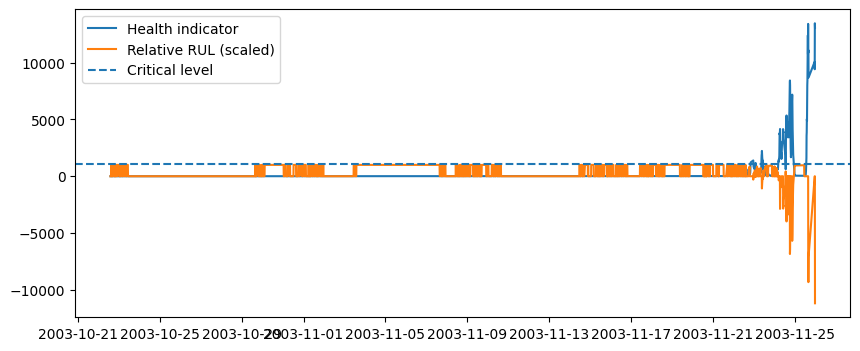

Series([], dtype: float64)


In [19]:
import datetime
plt.figure(figsize=(10,4))
plt.plot(smoothed_error, label="Health indicator")
plt.plot((RUL_health / RUL_health.max())*1000, label="Relative RUL (scaled)")
plt.axhline(critical_health_threshold, linestyle='--', label="Critical level")
plt.legend()
plt.show()

print(RUL_health[datetime.datetime.strptime("2004/02/17 11:00:00", "%Y/%m/%d %H:%M:%S"):])

Changing to monotonic damage accumulation
- After the damage spike, dont decrease RUL back down to baseline

<hr>

<ins>Using Cummulative Summative:</ins> <br>
cumsum([1, 3, 5, 7])
1. 1
2. 4
3. 9
4. 16


<ins>Explanation:</ins>
1. 1
2. 1+3 = 4
3. 4+5 = 9
4. 9+7 = 16

first anomaly:  2003-11-22 19:56:56
first over threshold value:  2003-11-22 20:16:56  with value  148.43924183426475
2003-11-22 20:16:56       148.439242
2003-11-22 23:14:58       450.690442
2003-11-22 23:16:56       744.197853
2003-11-22 23:26:56       706.987960
2003-11-22 23:36:56       671.638562
                           ...      
2003-11-25 16:07:32     93185.807342
2003-11-25 23:13:21     97527.807645
2003-11-25 23:19:56    101003.183026
2003-11-25 23:29:56    108353.755498
2003-11-25 23:39:56    114962.875720
Length: 301, dtype: float64
Critical damage score:  0.0
RUL Estimation begins:  2003-10-22 13:39:13

Beginning of dimishinment of RUL  2003-11-24 20:47:32
damage rate at this time:  35.58181810032855


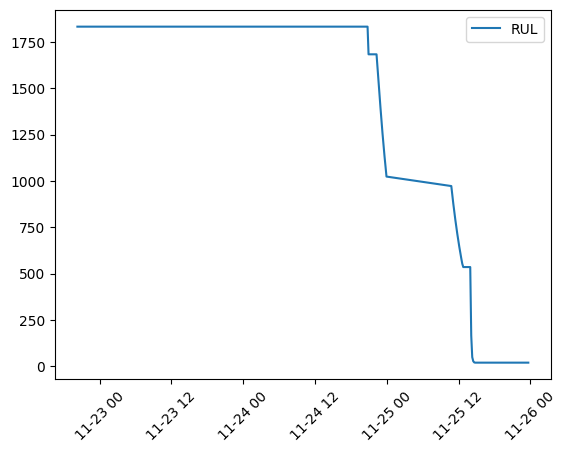

In [ ]:
# Temp block - Trial and error (testing block)

print("first anomaly: ", first_abnormal_idx)
ALPHA = .95 

e = np.maximum(smoothed_error - threshold, 0)
damage = pd.Series(index=e.index, dtype=float)
damage.iloc[0] = 0


for i in range(1, len(e)):
    damage.iloc[i] = (ALPHA * damage.iloc[i-1]) + e.iloc[i]

# NOTE, the damage increases dramatically over time. Current time writing this note
# The RUL dimishes more near the end as these are much more impactful
print("first over threshold value: ", damage.loc[damage>0].index[0], " with value ", damage.loc[damage>0][0] )
print(damage.loc[damage>0])
# print(damage)#.plot()

# Same damage-rate cacluation (difference between neighbours identifies contiguous changes)
WINDOW = 10
damage_rate = damage.diff(WINDOW) / WINDOW
eps = damage_rate[damage_rate > 0].quantile(.1)
damage_rate = damage_rate.clip(lower=eps) # clip values to > .000001

# "In historical data, 99.5% of the time damage was below "
critical_damage_score = damage.quantile(.05)
print("Critical damage score: ", critical_damage_score)


active = damage > 0
RUL = pd.Series(index=damage.index, dtype=float)
RUL[active] = (critical_damage_score - damage[active]) / damage_rate[active]
# RUL.plot()

# BOOL-Series, Get where confident degration is real
confidence = (damage > damage.quantile(.75)) #(damage > damage.quantile(.75))
# RUL.plot()

RUL.loc[confidence] = np.minimum.accumulate(
    RUL.loc[confidence][::-1]
)[::-1]
RUL = RUL.abs()
# RUL.plot()

print("RUL Estimation begins: ", RUL.index[0])

beginning_of_RUL_diminish = RUL[RUL>1750].index[-1]
print("\nBeginning of dimishinment of RUL ", beginning_of_RUL_diminish)
print("damage rate at this time: ", damage_rate[beginning_of_RUL_diminish - datetime.timedelta(hours=0)])
# I dunno

# plt.plot(damage_rate, label="Damage Rate")
plt.plot(RUL, label="RUL")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [116]:
damage = smoothed_error.copy()
# Set Non-Impactful rows (below threshold) to 0 - This brings ALL erros down by (-threshold)
# This is the same as doing:
# excess = smoothed_err - thres; (sub threshold from each error reading)
# excess_clipped = excess[excess < 0] = 0; (Set negative values to 0)
excess = np.maximum(smoothed_error - threshold, 0)
# print(excess.loc[excess > 0])




# print(threshold)
# damage[first_abnormal_idx:] = 0 # Below breaking threshold, not damaged, set to 0 to have no effect
damage = excess.cumsum() # Accumalative - retains previous errors
print(damage)
print(f"First anomaly: {damage[first_abnormal_idx]}")

WINDOW = 10
damage_rate = damage.diff(WINDOW) / WINDOW
damage_rate = damage_rate.clip(lower=1e-6) # clip values to > .000001


baseline = 5
critical_damage_threshold = baseline * damage[damage > 0].median() # Live 
critical_damage_threshold = 1.05 * damage.iloc[-1]
print(f"critical_damage_threshold ({critical_damage_threshold}) = 1.05 * {damage.iloc[-1]}")


# TODO
# Maybe try scaling damage down to make RUL less sensitive - already usnig cumsum to retain
# previous damage spikes
a = (critical_damage_threshold - damage)
print(a)
RUL_health_history = damage / damage_rate
# RUL_health = np.clip(RUL_health, 0, None)


2003-10-22 13:39:13         0.000000
2003-10-22 13:44:13         0.000000
2003-10-22 13:49:13         0.000000
2003-10-22 13:54:13         0.000000
2003-10-22 13:59:13         0.000000
                           ...      
2003-11-25 16:07:32    346707.943625
2003-11-25 23:13:21    355709.234294
2003-11-25 23:19:56    364061.000058
2003-11-25 23:29:56    376461.731681
2003-11-25 23:39:56    388488.539678
Length: 2137, dtype: float64
First anomaly: 0.0
critical_damage_threshold (407912.9666621062) = 1.05 * 388488.53967819636
2003-10-22 13:39:13    407912.966662
2003-10-22 13:44:13    407912.966662
2003-10-22 13:49:13    407912.966662
2003-10-22 13:54:13    407912.966662
2003-10-22 13:59:13    407912.966662
                           ...      
2003-11-25 16:07:32     61205.023038
2003-11-25 23:13:21     52203.732368
2003-11-25 23:19:56     43851.966604
2003-11-25 23:29:56     31451.234981
2003-11-25 23:39:56     19424.426984
Length: 2137, dtype: float64


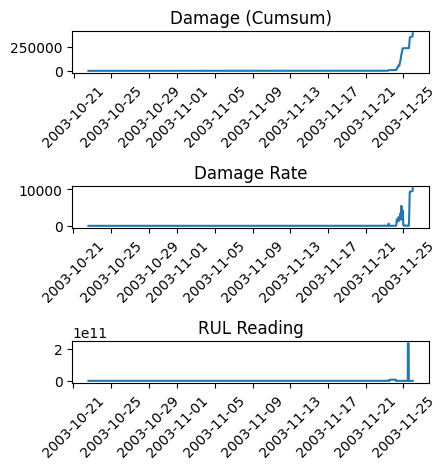

In [72]:
# Ploting
damage_plot = plt.subplot2grid((3,3), (0,0), colspan=2)
damage_rate_plot = plt.subplot2grid((3,3), (1,0), colspan=2)
RUL_plot = plt.subplot2grid((3,3), (2,0), colspan=2)


# Can see it retains the previous bearing faults 
# Damage
damage_plot.plot(damage)
damage_plot.set_title("Damage (Cumsum)")
damage_plot.tick_params(axis="x", labelrotation=45)


# Damage Rate
damage_rate_plot.plot(damage_rate)
damage_rate_plot.set_title("Damage Rate")
damage_rate_plot.tick_params(axis="x", labelrotation=45)

# Rul
RUL_plot.plot(RUL_health_history)
RUL_plot.set_title("RUL Reading")
RUL_plot.tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.show()


First burst (2003-11-22 19:56:56) with detected anomaly & onwards:
2003-11-22 19:56:56     0.000000
2003-11-22 20:06:56     0.000000
2003-11-22 20:16:56    10.000000
2003-11-22 23:14:58    10.000000
2003-11-22 23:16:56    10.000000
                         ...    
2003-11-25 16:07:32    37.277286
2003-11-25 23:13:21    37.416872
2003-11-25 23:19:56    37.895426
2003-11-25 23:29:56    37.702304
2003-11-25 23:39:56    37.858422
Length: 141, dtype: float64


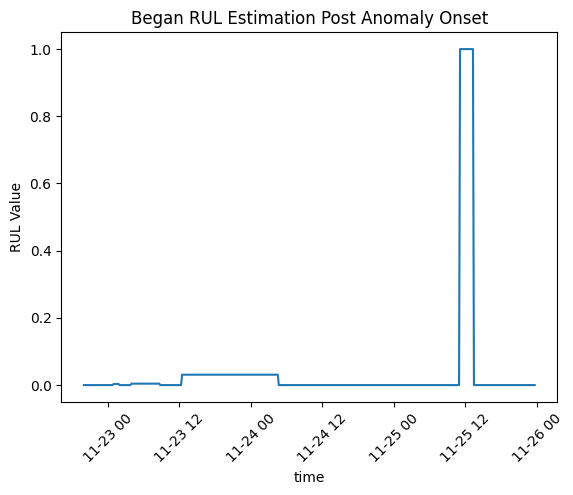

In [73]:
RUL_Health_series = pd.Series(RUL_health_history)
RUL_post_onset = RUL_Health_series[first_abnormal_idx:]

print(f"First burst ({first_abnormal_idx}) with detected anomaly & onwards:\n{RUL_post_onset[RUL_Health_series < 100]}")


plt.plot(RUL_post_onset / RUL_post_onset.max())
plt.title("Began RUL Estimation Post Anomaly Onset")
plt.ylabel("RUL Value")
plt.xlabel("time")
plt.xticks(rotation=45)
plt.show()

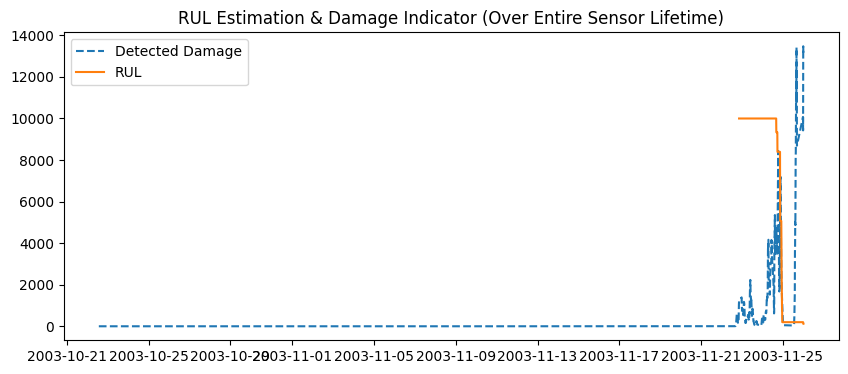

Series([], dtype: float64)


In [118]:
import datetime

plt.figure(figsize=(10,4))
plt.title("RUL Estimation & Damage Indicator (Over Entire Sensor Lifetime)")
plt.plot(smoothed_error, label="Detected Damage", linestyle="--")
plt.plot((RUL / RUL.max())*10000, label="RUL")
plt.legend()
plt.show()

print(RUL_health[datetime.datetime.strptime("2004/02/17 11:00:00", "%Y/%m/%d %H:%M:%S"):])